# California Housing Price Prediction

This project builds a regression model to predict median house prices in California
using demographic and geographic features from the California Housing dataset
(scikit-learn). The goal is to compare a simple linear model against an ensemble
model and identify which features drive price most strongly.


In [1]:
# Import required libraries for data analysis, visualization, and machine learning
from sklearn.datasets import fetch_california_housing
import pandas as pd


## 1. Data Loading
##Loading the California Housing dataset from scikit-learn and converting it into a
##pandas DataFrame for analysis.
data = fetch_california_housing()
# Convert the dataset into a pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target  # Add the target column
# Display the first five rows of the DataFrame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


2. Initial Data Check

Checking the shape, data types, summary statistics, and missing values to confirm the dataset is clean and ready for exploratory analysis. No null values were found.

In [ ]:


# Display the shape of the DataFrame
print(df.shape)
# Get the concise summary of the DataFrame
print(df.info())
# Get the statistical summary of the DataFrame
print(df.describe())
# Check for null values
df.isnull().sum()
# Create a copy of the DataFrame to use for further cleaning
df_cleaned = df.copy()


(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.

3. Exploratory Data Analysis — Correlation Heatmap
Visualizing correlations between all features and the target (Price) to understand relationships and identify potential multicollinearity before feature selection.

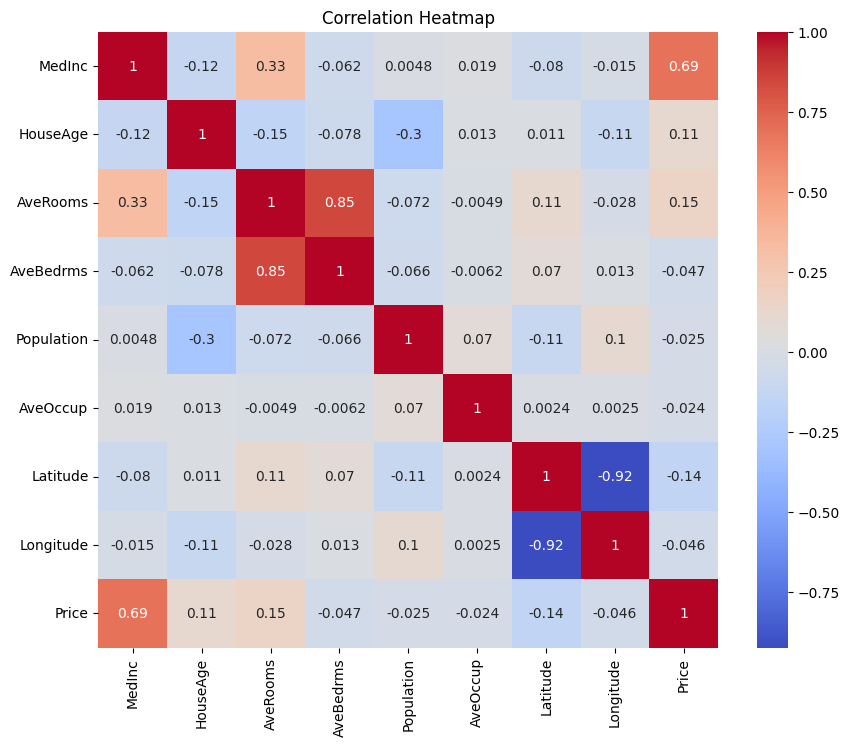

In [2]:
# Importing visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
# Set the figure size for better readability
plt.figure(figsize=(10, 8))

# Plot a heatmap to show the correlation between features
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Display the correlation matrix to see relationships between features
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


4. Feature Selection
Based on the correlation analysis, `MedInc`, `HouseAge`, `AveRooms`, `Latitude`,
and `Longitude` were selected as predictors. `AveBedrms` was excluded due to high
correlation with `AveRooms` (0.85), which risks multicollinearity. `Population`
and `AveOccup` showed weak correlation with Price and were dropped to keep the
model focused on the strongest signals.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Select important features for prediction
x=df[['MedInc','HouseAge','AveRooms','Latitude','Longitude']]
y=df['Price']
# Split the dataset into training and testing sets (80% train, 20% test)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print(x_train.shape) # Shape of training features
print(x_test.shape)   # Shape of testing features
print(y_train.shape)  # Shape of training target
print(y_test.shape)   # Shape of testing target


(16512, 5)
(4128, 5)
(16512,)
(4128,)


5. Linear Regression — Baseline Model
Training a Linear Regression model as a baseline to compare against a more complex
ensemble method later.

In [ ]:
# Create a Linear Regression model
model = LinearRegression()
# Train the model using the training data
model.fit(x_train, y_train)
# Predict target values for the test data
y_pred = model.predict(x_test)
# Calculate Mean Squared Error (MSE) to evaluate prediction accuracy
mse = mean_squared_error(y_test, y_pred)
# Calculate R-squared (R²) to measure model performance
r2 = r2_score(y_test, y_pred)
# Print performance metrics
print("Mean Squared Error:", mse) # Lower MSE indicates better performance
print("R-squared:", r2)            # R² closer to 1 means better model
# Print model scores on test and train data
print(model.score(x_test,y_test))   # R² on test data
print(model.score(x_train, y_train)) # R² on training data
# Print model intercept and coefficients
print("Intercept:", model.intercept_)  # Constant term in the regression equation
print("Coefficients:", model.coef_)     # Weights for each feature



Mean Squared Error: 0.5485707128789089
R-squared: 0.5813744243302474
0.5813744243302474
0.5984528848684194
Intercept: -39.10264663401056
Coefficients: [ 0.37118049  0.00980142  0.01959147 -0.45904948 -0.46586511]


Actual vs Predicted — Linear Regression

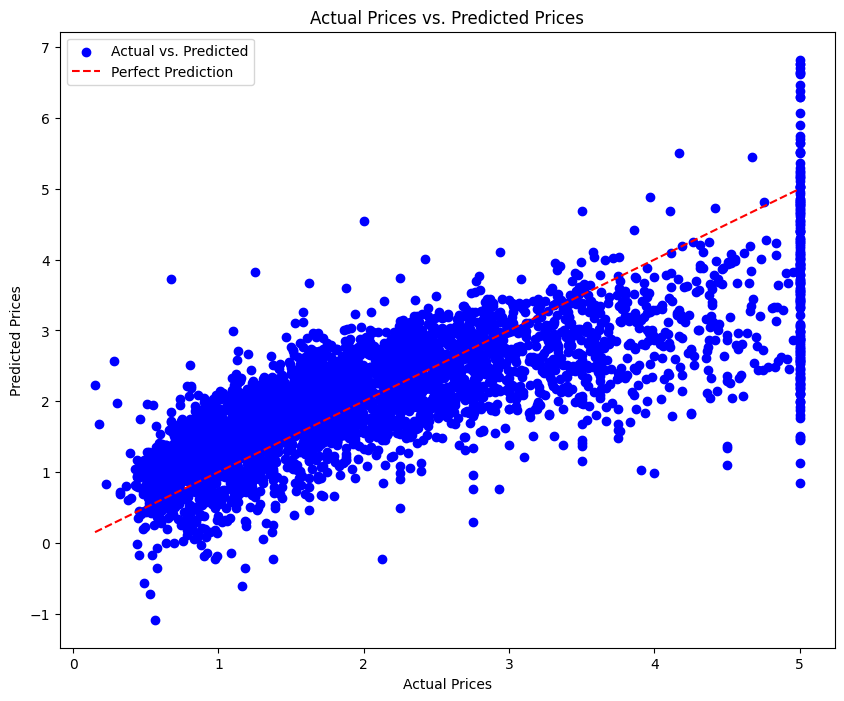

In [ ]:
# Import the matplotlib library for plotting
import matplotlib.pyplot as plt
# Set the size of the plot
plt.figure(figsize=(10,8))
# Create a scatter plot comparing actual vs predicted prices
plt.scatter(y_test, y_pred, color='blue', label='Actual vs. Predicted')
# Plot a red dashed line representing a perfect prediction (where predicted = actual)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color='red',linestyle='--',label='Perfect Prediction')
# Label the axes and add a title
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual Prices vs. Predicted Prices')
# Add a legend to the plot
plt.legend()
# Display the plot
plt.show()

6. Random Forest Regression
Training a Random Forest Regressor on the same features to see if a non-linear,
ensemble-based approach improves prediction accuracy over the linear baseline.

In [ ]:
# Import necessary libraries for model building and evaluation
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Define features (independent variables) and target (dependent variable)
x=df[['MedInc','HouseAge','AveRooms','Latitude','Longitude']]
y=df['Price']
# Split the dataset into training and testing sets (80% train, 20% test)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
# Print the shapes of the splits to verify dimensions
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
# Initialize the Random Forest Regressor with 100 trees and fixed random state
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# Train the model on the training data
rf_model.fit(x_train, y_train)
# Predict house prices on the test data
y_pred_rf = rf_model.predict(x_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# Evaluate model performance using MAE, RMSE, and R² Score
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))  # RMSE is the square root of MSE
r2 = r2_score(y_test, y_pred_rf)  # R² Score indicates the goodness of fit
# Print evaluation metrics
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")


(16512, 5)
(4128, 5)
(16512,)
(4128,)
MAE: 0.3256620519864342
RMSE: 0.5005945419797837
R² Score: 0.8087658894123655


Actual vs Predicted — Random Forest

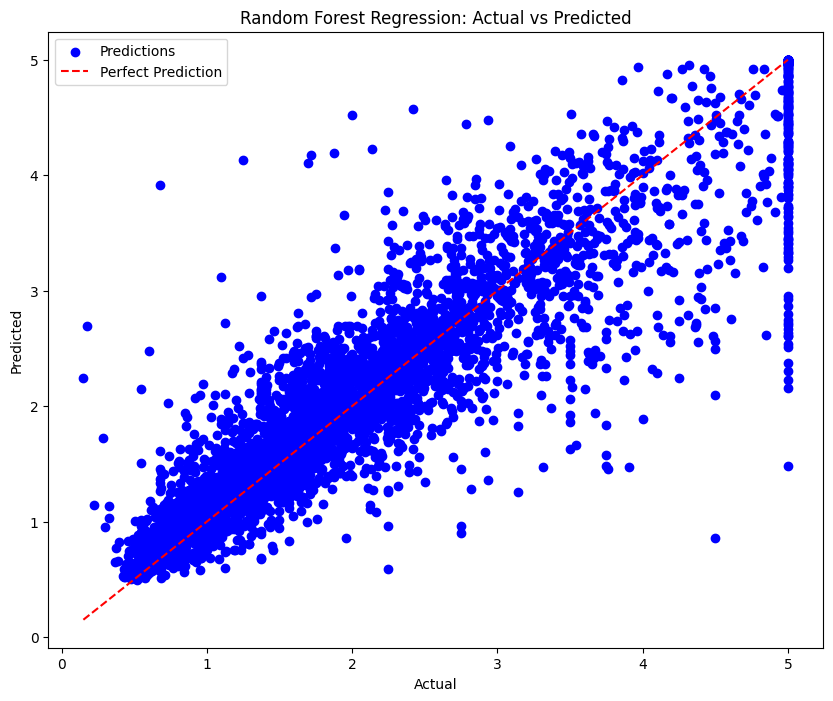

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.scatter(y_test, y_pred_rf, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest Regression: Actual vs Predicted')
plt.legend()
plt.show()


7. Feature Importance
Examining which features the Random Forest model relied on most heavily, to
validate the feature selection choices made earlier.

<Axes: title={'center': 'Feature Importance'}>

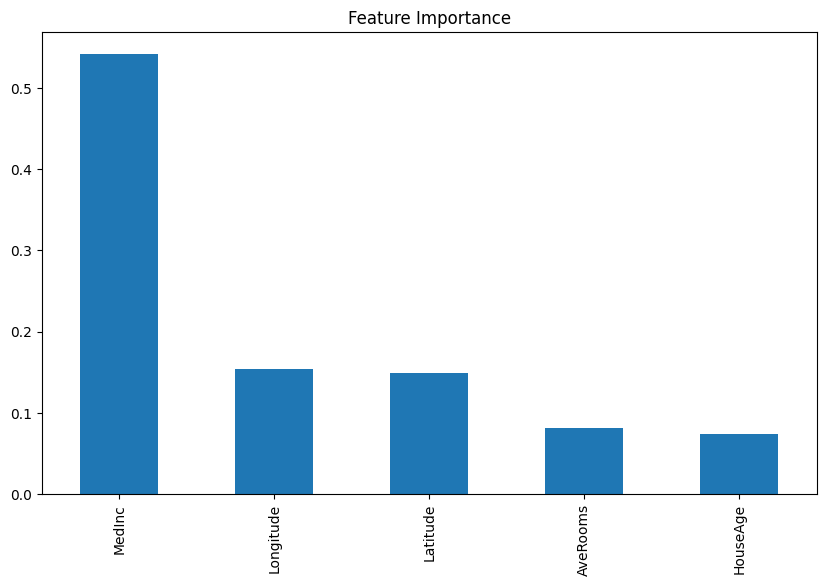

In [ ]:
import pandas as pd
# Create a Series with feature importances from the trained Random Forest model
# The index is set to the feature names for easy reference
feature_importance = pd.Series(rf_model.feature_importances_, index=x.columns)
# Sort the feature importances in descending order and plot them as a bar chart
feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,6), title='Feature Importance')


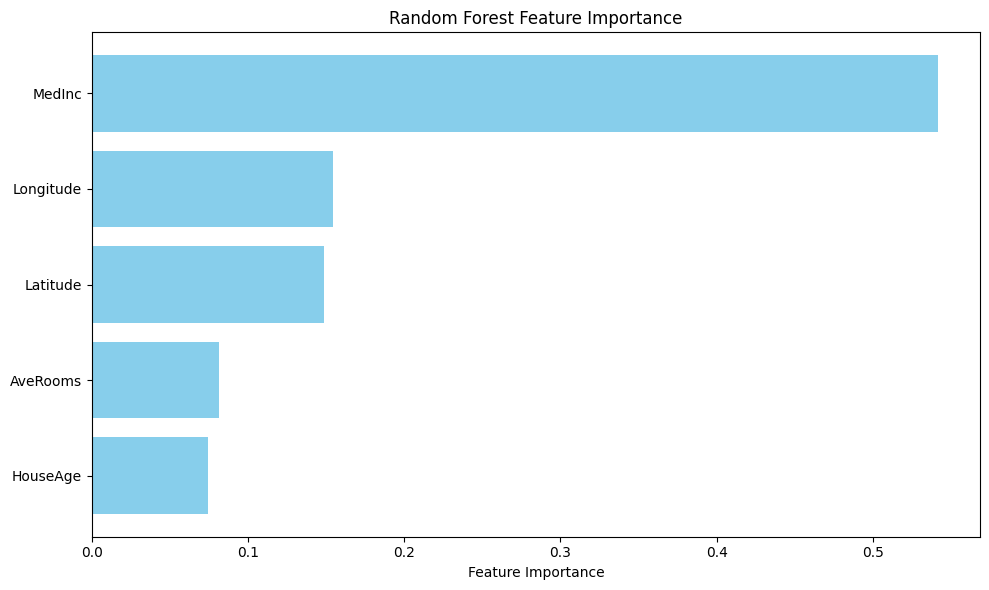

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Combine features and importances into a sorted DataFrame
import pandas as pd
import numpy as np

feature_names = x_train.columns
importances = rf_model.feature_importances_

# Create a sorted DataFrame
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=True)  # Ascending for better barh visualization

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Download
from google.colab import files
files.download('feature_importance.png')



## Conclusion
Random Forest significantly outperformed Linear Regression (R² 0.81 vs 0.58,
MAE 0.33), showing that housing prices in this dataset are driven by non-linear
relationships the linear model couldn't capture. Median income and location
(latitude/longitude) emerged as the strongest predictors of price.